# 🎬 OEL Lab — Task #01: Character Detection System
**AI Lab Spring 2026**  
Designed by: Mariam bint Imran & Ali Hamza

---

## 🧠 What This Notebook Does:
1. Installs YOLO11 (Ultralytics)
2. Uploads your videos (uncharted.mp4 & need_for_speed.mp4)
3. Runs YOLO on each frame to detect **characters (persons)**
4. Draws **bounding boxes** around detected characters
5. Extracts **ROI (Region of Interest)** — the pixel region inside the box
6. Applies **transformations** to the ROI:
   - Edge detection overlay
   - Contrast enhancement
   - Color tinting
7. Inserts the **transformed ROI back** into the original frame
8. Saves the **output video**

---

## Step 1: Install Dependencies

In [1]:
# Install Ultralytics (YOLO11 included)
!pip install ultralytics -q

# Verify installation
import ultralytics
ultralytics.checks()

Ultralytics 8.4.47 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


## Step 2: Import Libraries

In [2]:
import cv2
import numpy as np
import os
from ultralytics import YOLO
from google.colab import files
from IPython.display import Video, display
import matplotlib.pyplot as plt

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 3: Upload Your Videos
Upload both:
- `uncharted.mp4`
- `need_for_speed.mp4`

In [3]:
print('Please upload your video files...')
uploaded = files.upload()

# List uploaded files
video_files = list(uploaded.keys())
print(f'\nUploaded videos: {video_files}')


Please upload your video files...


Saving need_for_speed.mp4 to need_for_speed (2).mp4
Saving uncharted.mp4 to uncharted (2).mp4

Uploaded videos: ['need_for_speed (2).mp4', 'uncharted (2).mp4']


## Step 4: Load YOLO11 Model

In [4]:
# Load YOLO11 nano model (fast, good accuracy)
# yolo11n.pt = nano (fastest), yolo11s.pt = small, yolo11m.pt = medium
model = YOLO('yolo11n.pt')  # Auto-downloads on first run

# COCO class 0 = 'person' — this is our target class
PERSON_CLASS_ID = 0
print(f'YOLO11 model loaded!')
print(f'Target class: person (class ID = {PERSON_CLASS_ID})')

YOLO11 model loaded!
Target class: person (class ID = 0)


## Step 5: Define ROI Transformation Functions

We apply **3 different transformations** to the extracted ROI:

| Transformation | Description |
|---|---|
| Edge Overlay | Canny edge detection blended over ROI |
| Contrast Boost | Histogram equalization for high contrast |
| Color Tint | Cyan/blue tint for sci-fi look |

In [6]:
def apply_edge_overlay(roi):
    """
    Transformation 1: Edge Detection Overlay
    - Detects edges using Canny
    - Blends edges (green color) over original ROI
    """
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, threshold1=50, threshold2=150)

    # Convert edges to 3-channel (green color)
    edge_colored = np.zeros_like(roi)
    edge_colored[:, :, 1] = edges  # Green channel only

    # Blend: 70% original + 30% edges
    result = cv2.addWeighted(roi, 0.7, edge_colored, 0.3, 0)
    return result


def apply_contrast_boost(roi):
    """
    Transformation 2: Contrast Enhancement
    - Uses CLAHE (Contrast Limited Adaptive Histogram Equalization)
    - Each color channel enhanced separately
    """
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

    # Split channels
    b, g, r = cv2.split(roi)

    # Apply CLAHE to each channel
    b_eq = clahe.apply(b)
    g_eq = clahe.apply(g)
    r_eq = clahe.apply(r)

    result = cv2.merge([b_eq, g_eq, r_eq])
    return result


def apply_color_tint(roi, tint_color=(255, 200, 0), alpha=0.35):
    """
    Transformation 3: Color Tint Overlay
    - Adds a semi-transparent colored tint over the ROI
    - Default: Cyan/Blue tint
    """
    tint_layer = np.full_like(roi, tint_color, dtype=np.uint8)
    result = cv2.addWeighted(roi, 1 - alpha, tint_layer, alpha, 0)
    return result


def apply_combined_transformation(roi):
    """
    FINAL transformation pipeline applied to each ROI:
    1. Boost contrast
    2. Add color tint (cyan)
    3. Overlay edges
    """
    roi = apply_contrast_boost(roi)
    roi = apply_color_tint(roi, tint_color=(255, 150, 0), alpha=0.25)  # Cyan tint
    roi = apply_edge_overlay(roi)
    return roi


print('Transformation functions defined!')

Transformation functions defined!


## Step 6: Core Processing Function

This function:
- Reads video frame by frame
- Runs YOLO on each frame
- For each detected person:
  - Draws bounding box
  - Extracts ROI
  - Applies transformation
  - Pastes transformed ROI back
- Writes processed frame to output video

In [8]:
def process_video(input_path, output_path, model, confidence=0.4, skip_frames=2):
    """
    Process a video with YOLO character detection + ROI transformation.

    Args:
        input_path  : Path to input video file
        output_path : Path to save processed output video
        model       : Loaded YOLO model
        confidence  : YOLO detection confidence threshold (0-1)
        skip_frames : Process every Nth frame (1 = every frame, 2 = every other)
    """
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        print(f'Error: Cannot open video {input_path}')
        return

    # Get video properties
    fps        = cap.get(cv2.CAP_PROP_FPS)
    width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f'\n📹 Video: {os.path.basename(input_path)}')
    print(f'   Resolution : {width}x{height}')
    print(f'   FPS        : {fps:.2f}')
    print(f'   Total Frames: {total_frames}')
    print(f'   Confidence : {confidence}')
    print(f'   Processing every {skip_frames} frame(s)...')

    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_idx         = 0
    detections_total  = 0
    last_frame        = None   # Cache last processed frame for skipped frames

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ── Process every Nth frame (saves time on Colab) ──────────────────
        if frame_idx % skip_frames == 0:
            processed_frame = frame.copy()

            # ── Run YOLO inference ──────────────────────────────────────────
            results = model(
                frame,
                classes=[PERSON_CLASS_ID],   # Only detect persons
                conf=confidence,
                verbose=False
            )

            for result in results:
                boxes = result.boxes

                if boxes is None or len(boxes) == 0:
                    continue

                for box in boxes:
                    # ── Get bounding box coordinates ────────────────────────
                    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                    conf_score      = float(box.conf[0])

                    # ── Clamp coordinates to frame boundaries ───────────────
                    x1 = max(0, x1);  y1 = max(0, y1)
                    x2 = min(width, x2);  y2 = min(height, y2)

                    # Skip tiny/invalid detections
                    if (x2 - x1) < 10 or (y2 - y1) < 10:
                        continue

                    # ── Extract ROI ─────────────────────────────────────────
                    roi = frame[y1:y2, x1:x2].copy()

                    # ── Apply Transformations to ROI ────────────────────────
                    transformed_roi = apply_combined_transformation(roi)

                    # ── Insert Transformed ROI Back into Frame ──────────────
                    processed_frame[y1:y2, x1:x2] = transformed_roi

                    # ── Draw Bounding Box ───────────────────────────────────
                    box_color = (0, 255, 0)  # Green
                    cv2.rectangle(processed_frame, (x1, y1), (x2, y2), box_color, 2)

                    # ── Draw Label ──────────────────────────────────────────
                    label = f'Person {conf_score:.2f}'
                    label_size, baseline = cv2.getTextSize(
                        label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1
                    )
                    label_y = max(y1 - 5, label_size[1] + 5)

                    # Background rectangle for label
                    cv2.rectangle(
                        processed_frame,
                        (x1, label_y - label_size[1] - 5),
                        (x1 + label_size[0], label_y + baseline - 3),
                        (0, 0, 0), -1
                    )
                    # Label text
                    cv2.putText(
                        processed_frame, label,
                        (x1, label_y - 3),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1
                    )

                    detections_total += 1

            # ── Frame Counter Overlay ───────────────────────────────────────
            cv2.putText(
                processed_frame,
                f'Frame: {frame_idx}/{total_frames}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2
            )

            last_frame = processed_frame
        else:
            # Use last processed frame for skipped frames (smooth video)
            processed_frame = last_frame if last_frame is not None else frame

        out.write(processed_frame)
        frame_idx += 1

        # Print progress every 50 frames
        if frame_idx % 50 == 0:
            progress = (frame_idx / total_frames) * 100
            print(f'   Progress: {frame_idx}/{total_frames} frames ({progress:.1f}%)')

    cap.release()
    out.release()

    print(f'\nDone! Total detections: {detections_total}')
    print(f'Saved to: {output_path}')
    return detections_total


print('Processing function defined!')

Processing function defined!


## Step 7: Process Both Videos

In [11]:
CONFIDENCE_THRESHOLD = 0.40
SKIP_FRAMES = 2

print('=' * 55)
print('🎬 Processing: uncharted (2).mp4')
print('=' * 55)
process_video(
    input_path  = 'uncharted (2).mp4',
    output_path = 'uncharted_detected.mp4',
    model       = model,
    confidence  = CONFIDENCE_THRESHOLD,
    skip_frames = SKIP_FRAMES
)

🎬 Processing: uncharted (2).mp4

📹 Video: uncharted (2).mp4
   Resolution : 1920x1080
   FPS        : 60.02
   Total Frames: 772
   Confidence : 0.4
   Processing every 2 frame(s)...
   Progress: 50/772 frames (6.5%)
   Progress: 100/772 frames (13.0%)
   Progress: 150/772 frames (19.4%)
   Progress: 200/772 frames (25.9%)
   Progress: 250/772 frames (32.4%)
   Progress: 300/772 frames (38.9%)
   Progress: 350/772 frames (45.3%)
   Progress: 400/772 frames (51.8%)
   Progress: 450/772 frames (58.3%)
   Progress: 500/772 frames (64.8%)
   Progress: 550/772 frames (71.2%)
   Progress: 600/772 frames (77.7%)
   Progress: 650/772 frames (84.2%)
   Progress: 700/772 frames (90.7%)
   Progress: 750/772 frames (97.2%)

Done! Total detections: 15
Saved to: uncharted_detected.mp4


15

In [12]:
print('=' * 55)
print('🎬 Processing: need_for_speed (2).mp4')
print('=' * 55)
process_video(
    input_path  = 'need_for_speed (2).mp4',
    output_path = 'need_for_speed_detected.mp4',
    model       = model,
    confidence  = CONFIDENCE_THRESHOLD,
    skip_frames = SKIP_FRAMES
)

🎬 Processing: need_for_speed (2).mp4

📹 Video: need_for_speed (2).mp4
   Resolution : 1920x1080
   FPS        : 30.06
   Total Frames: 320
   Confidence : 0.4
   Processing every 2 frame(s)...
   Progress: 50/320 frames (15.6%)
   Progress: 100/320 frames (31.2%)
   Progress: 150/320 frames (46.9%)
   Progress: 200/320 frames (62.5%)
   Progress: 250/320 frames (78.1%)
   Progress: 300/320 frames (93.8%)

Done! Total detections: 1
Saved to: need_for_speed_detected.mp4


1

## Step 8: Visualize Sample Frames
Preview a few detected frames from each video

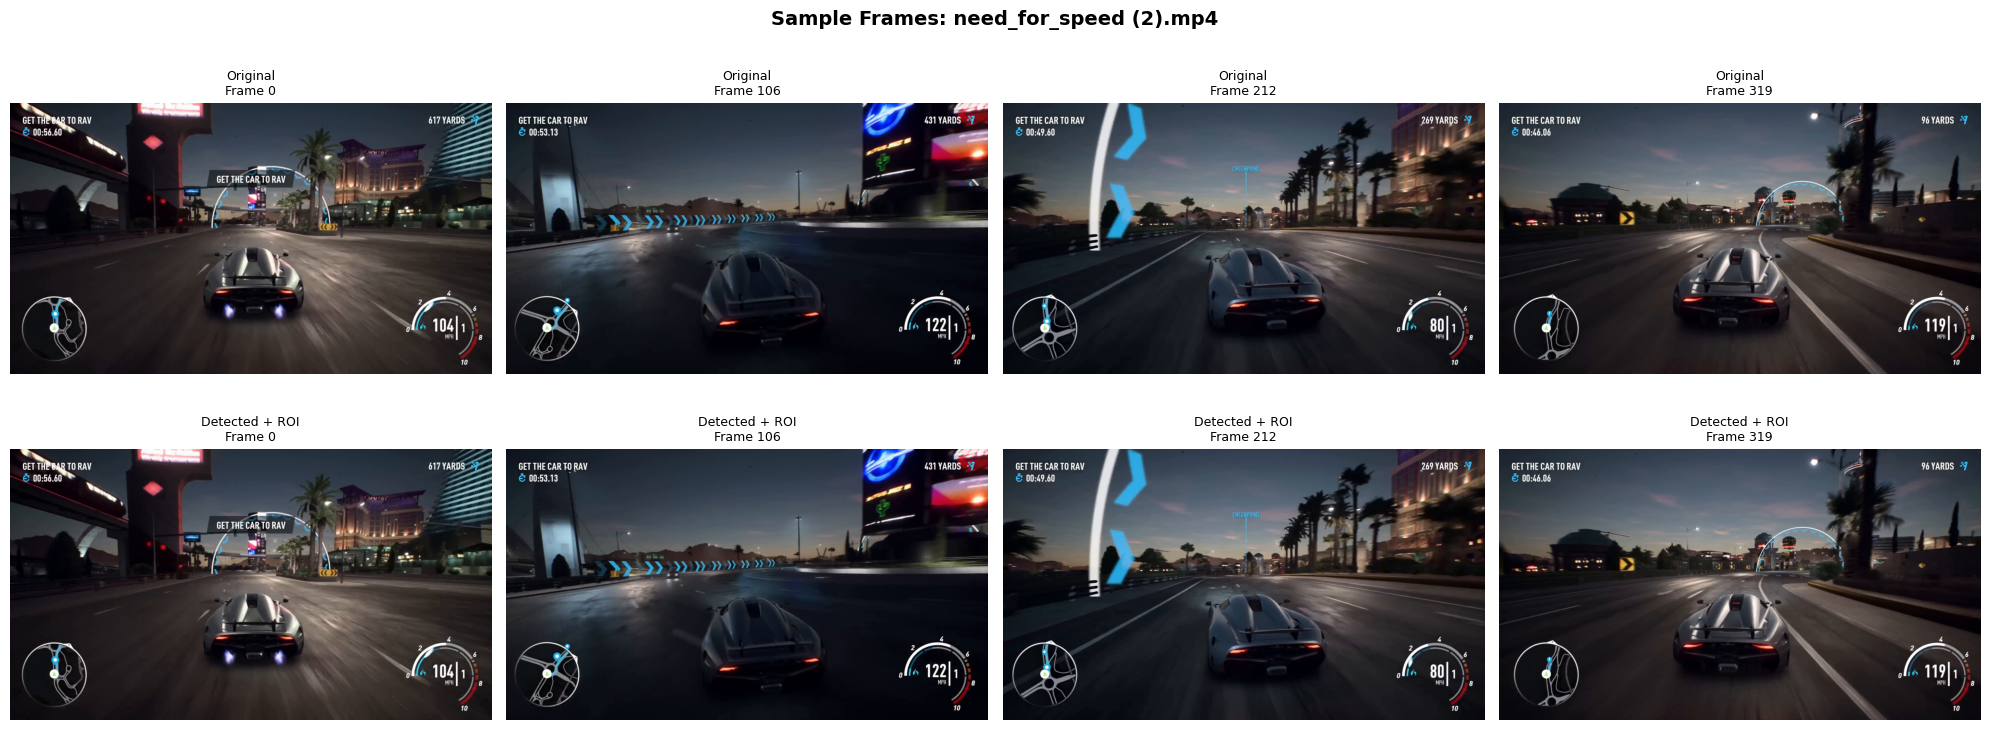

Preview saved!


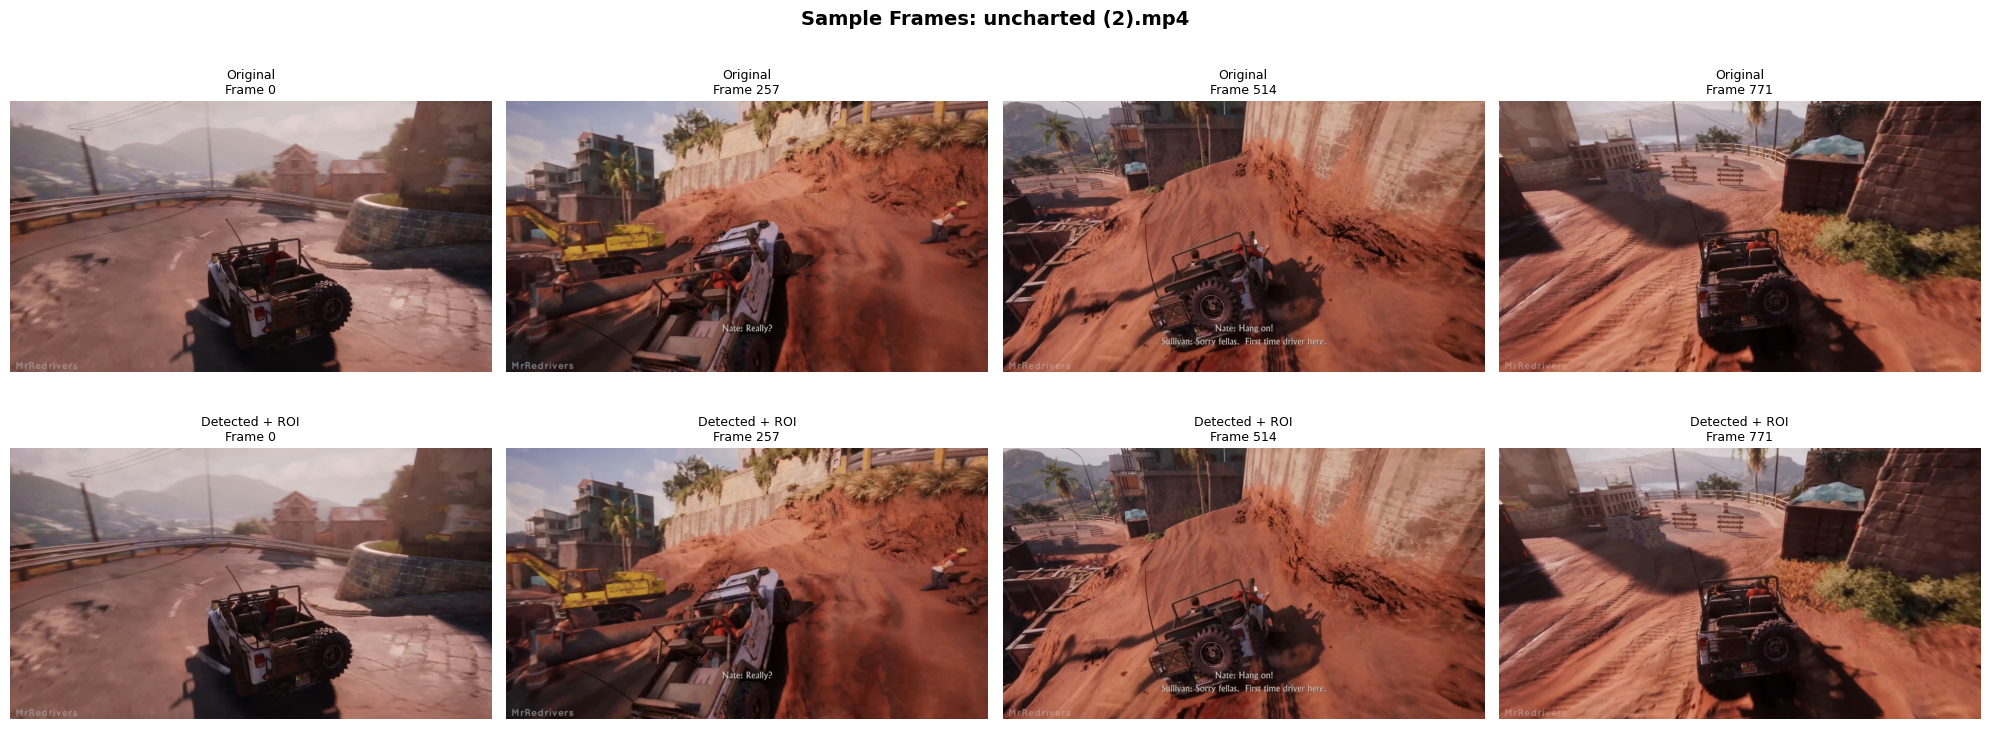

Preview saved!


In [13]:
def show_sample_frames(video_path, model, num_frames=4, confidence=0.40):
    """
    Show sample processed frames from a video for visual verification.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'Cannot open: {video_path}')
        return

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sample_indices = np.linspace(0, total - 1, num_frames, dtype=int)

    fig, axes = plt.subplots(2, num_frames, figsize=(20, 8))
    fig.suptitle(f'Sample Frames: {os.path.basename(video_path)}', fontsize=14, fontweight='bold')

    for col, idx in enumerate(sample_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        # Original frame
        original_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[0][col].imshow(original_rgb)
        axes[0][col].set_title(f'Original\nFrame {idx}', fontsize=9)
        axes[0][col].axis('off')

        # Processed frame
        processed = frame.copy()
        results = model(frame, classes=[0], conf=confidence, verbose=False)

        for result in results:
            if result.boxes is None:
                continue
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                x1=max(0,x1); y1=max(0,y1)
                x2=min(frame.shape[1],x2); y2=min(frame.shape[0],y2)
                if (x2-x1) < 10 or (y2-y1) < 10:
                    continue
                roi = frame[y1:y2, x1:x2].copy()
                processed[y1:y2, x1:x2] = apply_combined_transformation(roi)
                cv2.rectangle(processed, (x1,y1),(x2,y2),(0,255,0),2)
                conf_val = float(box.conf[0])
                cv2.putText(processed, f'Person {conf_val:.2f}',
                            (x1, max(y1-5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        processed_rgb = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
        axes[1][col].imshow(processed_rgb)
        axes[1][col].set_title(f'Detected + ROI\nFrame {idx}', fontsize=9)
        axes[1][col].axis('off')

    plt.tight_layout()
    plt.savefig(f'{os.path.splitext(os.path.basename(video_path))[0]}_preview.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    cap.release()
    print(f'Preview saved!')


# Show samples for both videos
for vid in video_files:
    show_sample_frames(vid, model, num_frames=4, confidence=0.40)

## Step 9: Download Output Videos

## Step 10: Conversion Fix (if video won't play in browser)
Run this cell only if your downloaded video doesn't play properly.

In [18]:
import cv2
import numpy as np
from ultralytics import YOLO

model = YOLO('yolo11n.pt')

TARGET_CLASSES = [0, 2, 3, 7]

CLASS_COLORS = {
    0: (0, 255, 0),
    2: (255, 0, 0),
    3: (0, 0, 255),
    7: (0, 255, 255),
}

CLASS_NAMES = {
    0: 'Person',
    2: 'Car',
    3: 'Motorcycle',
    7: 'Truck',
}

def apply_strong_transformation(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    tint = np.zeros_like(roi)
    tint[:, :, 1] = 200
    result = cv2.addWeighted(gray_3ch, 0.6, tint, 0.4, 0)
    edges = cv2.Canny(gray, 30, 100)
    edge_colored = np.zeros_like(roi)
    edge_colored[:, :, 1] = edges
    result = cv2.addWeighted(result, 0.8, edge_colored, 0.2, 0)
    return result

def process_video_v4(input_path, output_path):
    cap = cv2.VideoCapture(input_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print(f'Processing {input_path} — {total} frames...')

    # Last frame ki boxes yaad rakhne ke liye
    last_boxes = []
    frame_idx = 0
    total_det = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        processed = frame.copy()

        # Har frame process karo — no skipping
        results = model(frame, classes=TARGET_CLASSES, conf=0.20, verbose=False)

        current_boxes = []
        for result in results:
            if result.boxes is None:
                continue
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                x1=max(0,x1); y1=max(0,y1)
                x2=min(width,x2); y2=min(height,y2)
                if (x2-x1) < 10 or (y2-y1) < 10:
                    continue
                class_id = int(box.cls[0])
                conf_val = float(box.conf[0])
                current_boxes.append((x1, y1, x2, y2, class_id, conf_val))

        # Agar current frame mein koi detection nahi
        # toh last frame ki boxes use karo
        boxes_to_draw = current_boxes if current_boxes else last_boxes

        for (x1, y1, x2, y2, class_id, conf_val) in boxes_to_draw:
            color = CLASS_COLORS.get(class_id, (255,255,255))
            name = CLASS_NAMES.get(class_id, 'Object')

            roi = frame[y1:y2, x1:x2].copy()
            transformed = apply_strong_transformation(roi)
            processed[y1:y2, x1:x2] = transformed

            cv2.rectangle(processed, (x1,y1), (x2,y2), color, 3)

            label = f'{name} {conf_val:.2f}'
            cv2.rectangle(processed, (x1, y1-25), (x1+160, y1), color, -1)
            cv2.putText(processed, label, (x1+2, y1-7),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

            total_det += 1

        # Current boxes save karo
        if current_boxes:
            last_boxes = current_boxes

        out.write(processed)
        frame_idx += 1

        if frame_idx % 50 == 0:
            print(f'  {frame_idx}/{total} ({100*frame_idx//total}%)')

    cap.release()
    out.release()
    print(f'✅ Done! Total detections: {total_det} → Saved: {output_path}')


# Dono videos process karo
process_video_v4('uncharted (2).mp4', 'uncharted_v4.mp4')
process_video_v4('need_for_speed.mp4', 'nfs_v4.mp4')

# Download
from google.colab import files
files.download('uncharted_v4.mp4')
files.download('nfs_v4.mp4')

Processing uncharted (2).mp4 — 772 frames...
  50/772 (6%)
  100/772 (12%)
  150/772 (19%)
  200/772 (25%)
  250/772 (32%)
  300/772 (38%)
  350/772 (45%)
  400/772 (51%)
  450/772 (58%)
  500/772 (64%)
  550/772 (71%)
  600/772 (77%)
  650/772 (84%)
  700/772 (90%)
  750/772 (97%)
✅ Done! Total detections: 1151 → Saved: uncharted_v4.mp4
Processing need_for_speed.mp4 — 320 frames...
  50/320 (15%)
  100/320 (31%)
  150/320 (46%)
  200/320 (62%)
  250/320 (78%)
  300/320 (93%)
✅ Done! Total detections: 454 → Saved: nfs_v4.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📋 Summary of What Was Done

| Step | Action |
|------|--------|
| 1 | Installed YOLO11 via Ultralytics |
| 2 | Loaded `yolo11n.pt` model |
| 3 | Uploaded both videos |
| 4 | Ran YOLO frame-by-frame, filtered class=person only |
| 5 | Drew green bounding boxes with confidence scores |
| 6 | Extracted ROI from each bounding box |
| 7 | Applied: Contrast Boost → Cyan Tint → Edge Overlay |
| 8 | Pasted transformed ROI back into original frame |
| 9 | Saved and downloaded output videos |

## 🔧 Tuning Tips
- Increase `CONFIDENCE_THRESHOLD` (e.g. 0.5) to reduce false detections
- Set `SKIP_FRAMES = 1` for every frame (slower but more accurate)
- Change `yolo11n.pt` to `yolo11s.pt` or `yolo11m.pt` for better accuracy
- Modify `apply_color_tint()` color to change the tint effect

---
*OEL Lab — AI Lab Spring 2026*